In [218]:
import torch.nn as nn
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [219]:
data_transfomer = transforms.ToTensor()

In [220]:
batch_size = 64
embedding_dim = 128
input_size = 28 #mnist row=col=28
patch_size = 4
number_of_patches = input_size//patch_size #49
num_transformer_blocks = 4
num_of_attention_heads=8
mlp_num_hidden_nodes=4*embedding_dim

In [221]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=data_transfomer #converting_to_tensor
)
val_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=data_transfomer #converting_to_tensor
)


In [222]:
#2 ways of embedding the patches 
#1st way - 
#mnist = 28x28, patch=4x4 so 7x7 =49 patches 
#patch shape = (1,4,4) (channel=grey, h,w)
#flatten patch = 1x4x4 = 16
#each of the 49 patches will be having a 16-d vector (49,16)
#for a batchsize of 64 it becomes = (64, 49,16) - (Batchsize, num_patches, patch_vector)
#using nn.Linear to embed from 16d -> 128d
#(64,49,16)-> after embedding = (64,49,embed_dim)


#2nd way-
#using Conv2d
#kernal = stride = patch_size
#input for Conv2d = (64,1,28,28)
#output spatial size = (28-4)/4+1 [(img - kernel)/stride]+1 = 7
#7x7 = number of total patches
#output dim = (64,embed_dim, 7,7)
#transpose and transform it to -> (64, 49,embed_dim)



In [223]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([64, 1, 28, 28])


In [224]:
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
images, labels = next(iter(val_loader))
print(images.shape)

torch.Size([64, 1, 28, 28])


In [225]:

patches = F.unfold(images, kernel_size=4, stride=4)
print("patch dim before transpose ",patches.shape)
patches=patches.transpose(1,2)
print("patch dim before transpose ",patches.shape)

patch dim before transpose  torch.Size([64, 16, 49])
patch dim before transpose  torch.Size([64, 49, 16])


In [226]:
embedd = nn.Linear(16,embedding_dim)
patches = embedd(patches)
print(patches.size())

torch.Size([64, 49, 128])


In [227]:
#CLS token is a learnable parameter/vector
cls_token = nn.Parameter(torch.randn(1,1,128))
cls_token = cls_token.expand(64,-1,-1)
patches = torch.cat((patches, cls_token), dim=1)
print(patches.size())

torch.Size([64, 50, 128])


In [228]:
#Position embedding is a learnable parameter
# as position embedding is a single set of values of positions, which is same accross all batches
# so no batchwise different position embedding

pos_emb = nn.Parameter(torch.randn(1,50,128))
patches = patches + pos_emb
print(patches.size())

torch.Size([64, 50, 128])


## Actual Implementation

In [229]:
#MultiHeadattention
#Create Q,K,V
#Split embedding into multiple heads
#apply attentoin independently
#concatenate heads back

class MultiHeadAttentionn(nn.Module):
    def __init__(self,embedding_dim, number_of_patches, num_of_attention_heads):
        super().__init__()
        
        #input projections
        self.embed_dim = embedding_dim
        self.num_heads = num_of_attention_heads
        self.dim_per_head = embedding_dim//num_of_attention_heads
        self.num_pathches = number_of_patches
        self.q = nn.Linear(self.embed_dim, self.embed_dim)
        self.k = nn.Linear(self.embed_dim, self.embed_dim)
        self.v = nn.Linear(self.embed_dim, self.embed_dim)
        #-----or----
        #qkv = nn.Linear(self.embed_dim, 3*self.embed_dim)
        #q,k,v = qkv.chunk(3,dim=-1)
        #creating a large matrix first and then cuttin git down

        #output projections
        self.proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.scale = self.dim_per_head**-0.5

    def split_heads(self,x):
        batch_size , seq_len , embed_dimm  = x.shape
        x = x.view(batch_size,  seq_len,self.num_heads, self.dim_per_head)
        return x.permute(0,2,1,3)
    #(64,8,50,16)
        #view applied so that we can break 128 into 8 x 16
        # permute is used to reorder dim, which is important becaues it goes like this ->
        #64 batches -> 8 heads -> 50 patches -> 16 dimensions
        #meaning, all 64 batches are given to all 8 heads, so each head will be receiving 50 patches per batch and 16 dim per head

    def merge_heads(self,x):
        x = x.permute(0,2,1,3).contiguous()
        batch_size , seq_len , num_headds , dim_per_headd = x.shape
        #.contiguous() because permute creates non contiguous tensor in memory. View() needs tensor to be stored in contiguous blocks
        return x.view(batch_size,seq_len,self.embed_dim)

    def forward(self,patches):
        Q = self.q(patches)
        K = self.k(patches)
        V = self.v(patches)

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        self.wei = Q@K.transpose(-1,-2)
        self.wei = self.wei * self.scale
        attn = F.softmax(self.wei, dim=-1)

        self.attention_map = attn


        self.output = attn@V

        self.output = self.merge_heads(self.output)
        return self.proj(self.output)









        


In [230]:
# MLP class
class MLP(nn.Module):
    def __init__(self, embedding_dim, dropout=0.1):
        super().__init__()
        self.num_hidden_nodes = mlp_num_hidden_nodes
        self.embedd_dim = embedding_dim
        self.fc1 = nn.Linear(self.embedd_dim, self.num_hidden_nodes)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(self.num_hidden_nodes, self.embedd_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self,x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x



In [231]:
#transformer Encoder Blocks
#using above defined classes

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedd_dimm, number_of_patches, num_attn_heads):
        super().__init__()
        self.embedd_dim = embedd_dimm
        self.num_patches  = number_of_patches
        self.num_attn_heads = num_attn_heads
        self.norm1 = nn.LayerNorm(self.embedd_dim)
        self.norm2 = nn.LayerNorm(self.embedd_dim)
        #for the tensor (64,50,128) applying layernorm only over 128
        #layernorm instead of batchnorm because we want normalization to be independent of batches 
        #and get applied uniformly throughout the all batches tensors
        self.attention = MultiHeadAttentionn(self.embedd_dim,self.num_patches, self.num_attn_heads)
        self.mlp = MLP(self.embedd_dim, dropout=0.2)

    def forward(self,x):
        residual1 = x
        x = self.norm1(x)
        attn_opt = self.attention(x)
        attn_opt = attn_opt+residual1
        residual2 = attn_opt
        x = self.norm2(attn_opt)
        mlp_opt = self.mlp(x)
        mlp_opt = mlp_opt+residual2

        return mlp_opt


In [232]:
class ViT(nn.Module):
    def __init__(self, batch_size, embedding_dim, input_size, patch_size, number_of_patches, num_transformer_blocks, num_of_attention_heads, mlp_num_hidden_nodes):
        super().__init__()

        self.batch_size = batch_size
        self.embedding_dim = embedding_dim
        self.input_size = input_size
        self.patch_size = patch_size
        self.number_of_patches = number_of_patches 
        self.num_transformer_blocks = num_transformer_blocks 
        self.num_of_attention_heads = num_of_attention_heads
        self.mlp_num_hidden_nodes = mlp_num_hidden_nodes
        self.emb_inp = 16

        self.head = nn.Linear(self.embedding_dim, 10)
        self.embedd = nn.Linear(self.emb_inp,embedding_dim)
        self.cls_token = nn.Parameter(torch.randn(1,1,self.embedding_dim))
        self.pos_emb = nn.Parameter(torch.randn(1,self.number_of_patches+1,self.embedding_dim))

        #transformer block stack
        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(self.embedding_dim, self.number_of_patches, self.num_of_attention_heads)
                for _ in range(self.num_transformer_blocks)
            ]
        )

    def forward(self,x):
        #convreting images to required patches
        self.patches = F.unfold(x, kernel_size=self.patch_size, stride=self.patch_size)
        self.patches=self.patches.transpose(1,2)

        #embedding the patches to required dimension
        
        
        self.patches = self.embedd(self.patches)

        #adding the [CLASS] token
        batch_sizee = x.shape[0]
        self.cls_tokens = self.cls_token.expand(batch_sizee,-1,-1)
        self.patches = torch.cat(( self.cls_tokens,self.patches), dim=1)

        #adding position embeddings
        
        self.patches = self.patches + self.pos_emb


        x = self.patches
        for block in self.blocks:
            x = block(x)
        
        cls = x[:,0] #shape becomes (64,128)
        logits = self.head(cls)

        return logits


        

In [233]:
model = ViT(
    batch_size=batch_size,
    embedding_dim=embedding_dim,
    input_size=input_size,
    patch_size=patch_size,
    number_of_patches=49,
    num_transformer_blocks=num_transformer_blocks,
    num_of_attention_heads=num_of_attention_heads,
    mlp_num_hidden_nodes=mlp_num_hidden_nodes
)

In [234]:
criterion = nn.CrossEntropyLoss()

In [235]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [236]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [237]:
model = model.to(device=device)

In [238]:
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        # print(output.shape)

        loss = criterion(output, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.800184423902205
Epoch 2, Loss: 0.20913292453892385
Epoch 3, Loss: 0.14166225833711085
Epoch 4, Loss: 0.11116064300905587
Epoch 5, Loss: 0.09479152361330177


In [239]:
# EVALUATION

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 97.39%


torch.Size([16, 8, 50, 50])


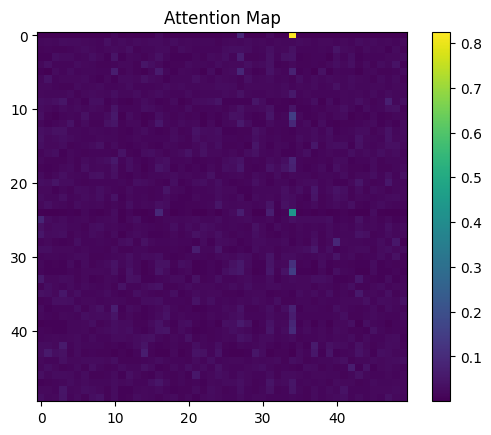

In [240]:
attn_map = model.blocks[0].attention.attention_map
print(attn_map.shape)
import matplotlib.pyplot as plt

head = 0
image_idx = 0

attention = attn_map[image_idx, head].detach().cpu()

plt.imshow(attention)
plt.colorbar()
plt.title("Attention Map")
plt.show()